# Netflix Data Cleaning, Analysis & Visualization

Project Description:

The goal of this project is to perform comprehensive data cleaning, exploratory data analysis (EDA), and visualization on the Netflix content catalog. By transforming raw data into a structured analytical dataset, the project aims to uncover meaningful insights related to strategic content acquisition, audience preferences, and global production trends. These insights will support Netflix in making informed, data-driven decisions to enhance its content strategy, improve viewer engagement, and strengthen its competitive advantage in the streaming industry.

In [2]:
#Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [3]:
#Loading the dataset

data=pd.read_csv("netflix1.csv")
data.head(5)

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [4]:
data.shape

(8790, 10)

There are 8790 rows and 10 columns in the dataset.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [6]:
data.describe()

,release_year
count,8790.000000
mean,2014.183163
std,8.825466
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
data.dtypes

show_id         object
type            object
title           object
director        object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
dtype: object

In [8]:
# Convert 'date_added' to datetime
data['date_added'] = pd.to_datetime(data['date_added'])

In [9]:
data.dtypes

show_id                 object
type                    object
title                   object
director                object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
dtype: object

Data Cleaning and Preprocessing

In [10]:
#checking if there any missing values and duplicate rows
print('\n--- Missing values per column ---')
print(data.isnull().sum())
print('\n--- Duplicate rows count ---')
print(data.duplicated().sum())


--- Missing values per column ---
show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

--- Duplicate rows count ---
0


There are no missing values and duplicated data.

In [11]:
#Feature Engineering
#Extract day, month and year from date_added column
data['year_added']=data['date_added'].dt.year
data['month_added']=data['date_added'].dt.month
data['day_added']=data['date_added'].dt.day

In [12]:
# Extract the numeric part of the duration column
data['duration_int'] = data['duration'].str.extract('(\d+)').astype(int)

# Rename 'duration' to 'duration_text' for clarity (keeping it for now)
data.rename(columns={'duration': 'duration_text'}, inplace=True)

# 4. Check the result of the duration column cleaning
print("\nDataFrame Head after cleaning:")
print(data[['type', 'date_added', 'year_added', 'month_added', 'duration_int', 'duration_text']].head())

print("\nValue Counts for type and duration_int:")
print(data.groupby('type')['duration_int'].describe())


DataFrame Head after cleaning:
      type date_added  year_added  month_added  duration_int duration_text
0    Movie 2021-09-25        2021            9            90        90 min
1  TV Show 2021-09-24        2021            9             1      1 Season
2  TV Show 2021-09-24        2021            9             1      1 Season
3    Movie 2021-09-22        2021            9            91        91 min
4    Movie 2021-09-24        2021            9           125       125 min

Value Counts for type and duration_int:
          count       mean        std  min   25%   50%    75%    max
type                                                                
Movie    6126.0  99.584884  28.283225  3.0  87.0  98.0  114.0  312.0
TV Show  2664.0   1.751877   1.550622  1.0   1.0   1.0    2.0   17.0


For movies, the longest movie has a duration of 312 minutes and the duration of the shortest movie is 3 minutes.

For TV Shows, the longest TV Show has a duration of 17 seasons and the duration of the shortest TV Show is 1 season.

In [13]:
# Split the comma-separated genres and count individual genres
#  Split 'listed_in' and explode the DataFrame
genres_data = data['listed_in'].str.split(', ', expand=True).stack().reset_index(level=1, drop=True).to_frame('genre')

In [14]:
genres_data

,genre
0,Documentaries
1,Crime TV Shows
1,International TV Shows
1,TV Action & Adventure
2,TV Dramas
...,...
8787,International TV Shows
8787,Romantic TV Shows
8787,TV Dramas
8788,Kids' TV


Data cleaning and preprocessing is completed. Next we are going to conduct EDA.

# Exploratory Data Analysis

There are the details of 8790 content titles including both movies and TV shows on Netflix in the dataset.

1) Content Type Distribution on Netflix

In [14]:
data['type'].value_counts()

Movie      6126
TV Show    2664
Name: type, dtype: int64

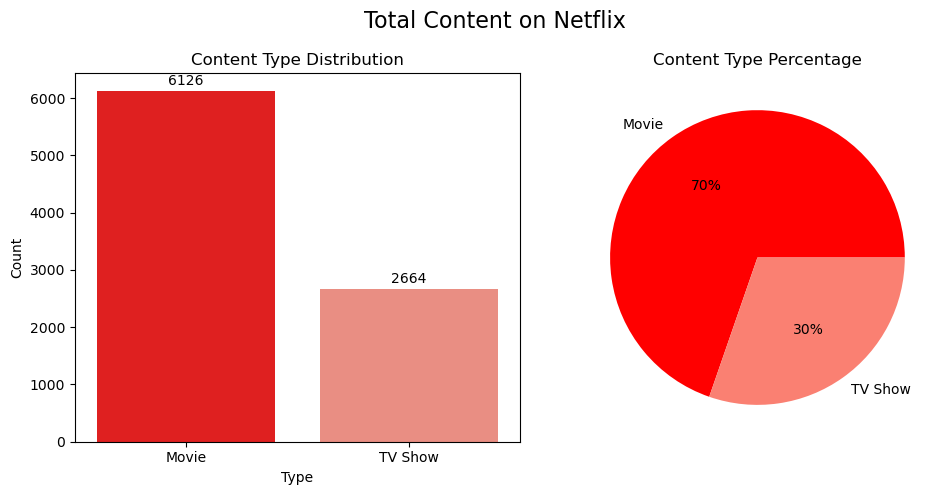

In [41]:
freq = data['type'].value_counts()
colors = ['red', 'salmon']
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

barplot = sns.countplot(x=data['type'], ax=axes[0], palette=colors)

axes[0].set_title("Content Type Distribution")
axes[0].set_xlabel("Type")
axes[0].set_ylabel("Count")
axes[0].grid(False)

for p in barplot.patches:
    height = p.get_height()
    axes[0].text(p.get_x() + p.get_width()/2,
                 height + 50,                 
                 f'{height}',
                 ha='center', va='bottom', fontsize=10)

axes[1].pie(freq,
            labels=freq.index,
            autopct='%.0f%%',
            colors=colors)

axes[1].set_title("Content Type Percentage")

plt.suptitle("Total Content on Netflix", fontsize=16)
plt.tight_layout()
plt.show()

Findings:

Approximately 70% of the content available on Netflix consists of movies, while the remaining 30% is made up of TV shows. This indicates that Netflix’s library is still heavily focused on movie content, although TV shows also form a significant portion of the platform’s offerings.

2) Content count by Release year

In [16]:
data['release_year'].value_counts()

2018    1146
2017    1030
2019    1030
2020     953
2016     901
        ... 
1966       1
1959       1
1925       1
1947       1
1961       1
Name: release_year, Length: 74, dtype: int64

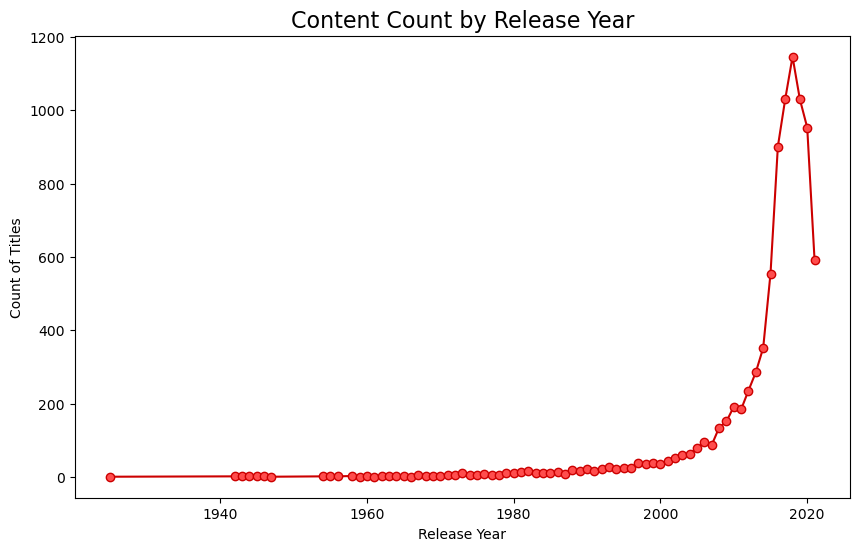

In [17]:
year_counts = data['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.plot(year_counts.index,year_counts.values,marker='o',color='#cc0000',markerfacecolor='#ff4d4d')

plt.title('Content Count by Release Year', fontsize=16)
plt.xlabel('Release Year')
plt.ylabel('Count of Titles')
plt.grid(False)
plt.show()



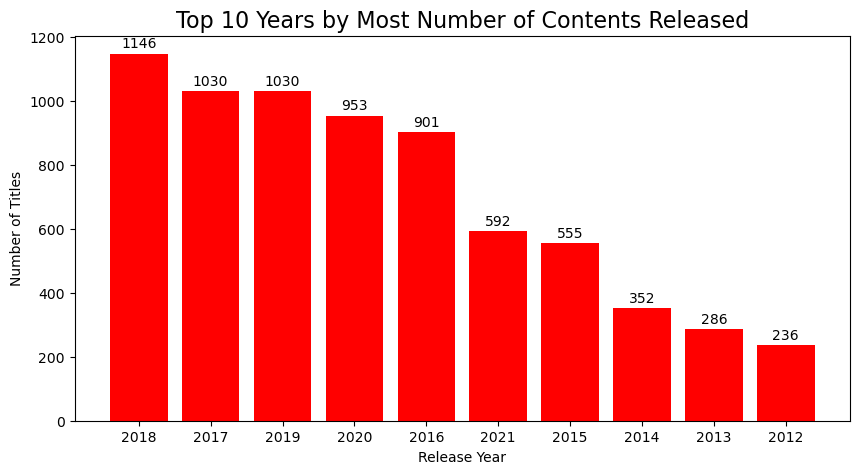

In [42]:
# Calculate top 10 years by content released counts
top10_years = data['release_year'].value_counts().head(10).sort_values(ascending=False)

plt.figure(figsize=(10,5))

bars = plt.bar(top10_years.index.astype(str),top10_years.values,color='red')

plt.title("Top 10 Years by Most Number of Contents Released", fontsize=16)
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(False)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 10,   
        str(height),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.show()

Findings:

Netflix started streaming in 2007. That event began the accumulation of releases.

Netflix content releases increased rapidly after 2015.

The highest number of titles were released in 2018.

2017 and 2019 were also strong years with over 1,000 releases each.

After 2019, the number of new releases started to decline.

The drop in 2020 and 2021 is likely due to COVID-19 production delays.

Very few titles exist before 1970, showing Netflix focuses mainly on modern and recent content.

3) Rating Distribution of Content on Netflix

In [19]:
data['rating'].value_counts()

TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: rating, dtype: int64

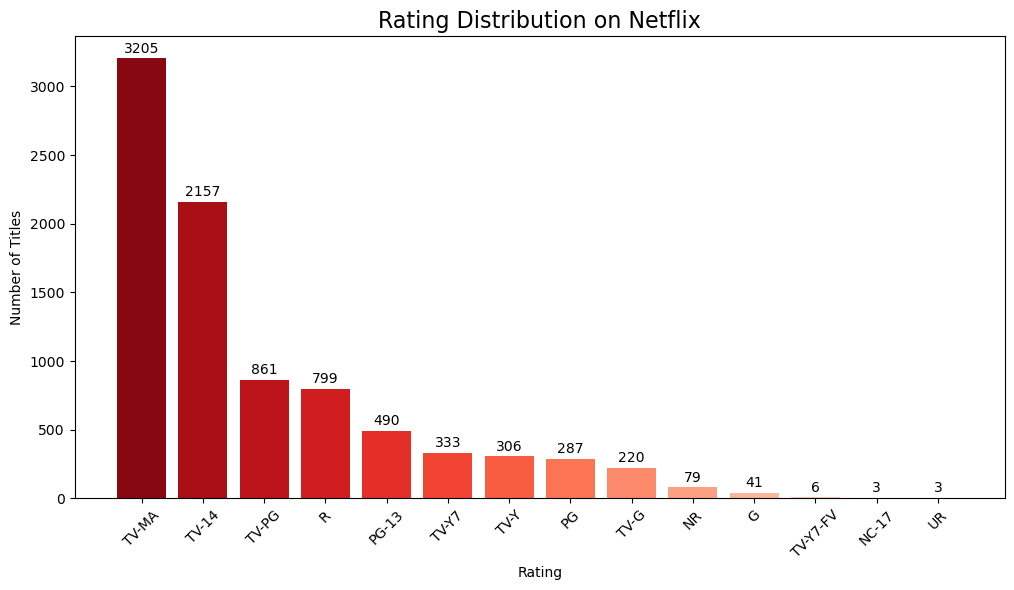

In [20]:
plt.figure(figsize=(12,6))

rating_counts = data['rating'].value_counts()

bars = plt.bar(rating_counts.index,rating_counts.values,color=sns.color_palette("Reds_r", len(rating_counts)))

plt.title("Rating Distribution on Netflix", fontsize=16)
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.grid(False)
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,     
        str(height),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.show()


Findings:

TV-MA (Mature Audience) is the most common rating with 3,205 titles.

TV-14 is the second most frequent rating with 2,157 titles.

Family and kids-friendly ratings such as TV-PG, TV-Y7, TV-Y, and TV-G appear much less frequently.

Movie-specific adult ratings like R (799 titles) and PG-13 (490 titles) also form a significant portion of the library.

Very few titles are rated NC-17, UR, and TV-Y7-FV, showing minimal focus on extreme or niche rating categories.

Overall, Netflix content is heavily focused on teen and adult audiences rather than children.

4) Countries With Most Content On Netflix

In [21]:
data['country'].value_counts()

United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
                  ... 
Iran                 1
West Germany         1
Greece               1
Zimbabwe             1
Soviet Union         1
Name: country, Length: 86, dtype: int64

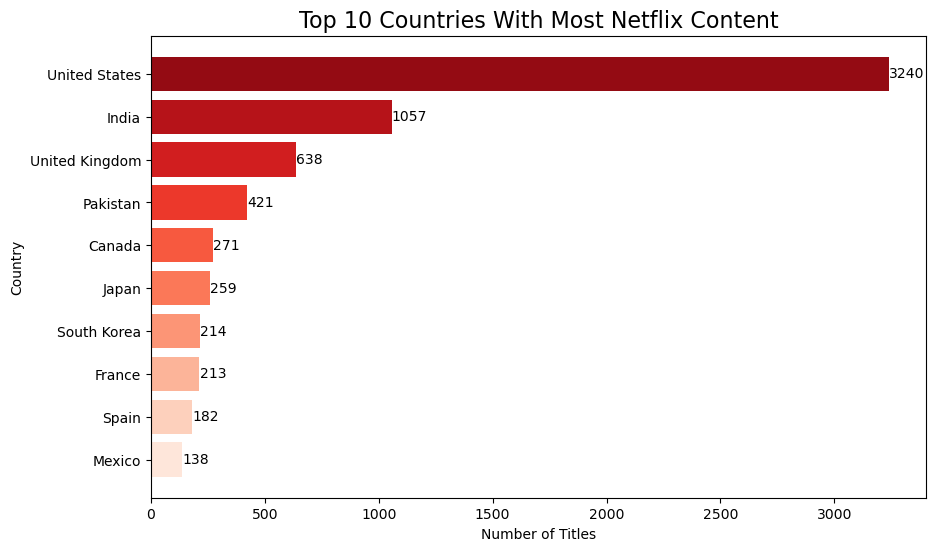

In [46]:

top10_countries = (
    data['country']
    .value_counts()
    .loc[lambda x: x.index != "Not Given"]
    .head(10)
    .reset_index()
    .rename(columns={'index': 'country', 'country': 'count'})
)

plt.figure(figsize=(10,6))

bars = plt.barh(top10_countries['country'],top10_countries['count'],color=sns.color_palette("Reds_r", 10))

plt.title("Top 10 Countries With Most Netflix Content", fontsize=16)
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.grid(False)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,                                     
        bar.get_y() + bar.get_height()/2,
        str(width),
        va='center',
        fontsize=10
    )

plt.gca().invert_yaxis()
plt.show()


Findings:

United States has the highest number of titles with 3,240 entries.

India ranks second with 1,057 titles, showing Netflix’s strong focus on the Indian market.

United Kingdom is third with 638 titles.

Pakistan (421) and Canada (271) also contribute a significant amount of content.

Asian countries like Japan (259) and South Korea (214) appear in the top 10, reflecting the popularity of Asian content globally.

European countries such as France (213) and Spain (182) also have a strong presence.

Some entries have “Not Given” (287) as country, indicating missing or unrecorded country data.

Netflix’s content library is dominated by the United States, but there is a rapidly growing contribution from India and other Asian countries, proving Netflix’s global expansion strategy.

5) Directors with Most Titles

In [47]:
data['director'].value_counts()

Not Given                         2588
Rajiv Chilaka                       20
Alastair Fothergill                 18
Raúl Campos, Jan Suter              18
Suhas Kadav                         16
                                  ... 
Matt D'Avella                        1
Parthiban                            1
Scott McAboy                         1
Raymie Muzquiz, Stu Livingston       1
Mozez Singh                          1
Name: director, Length: 4528, dtype: int64

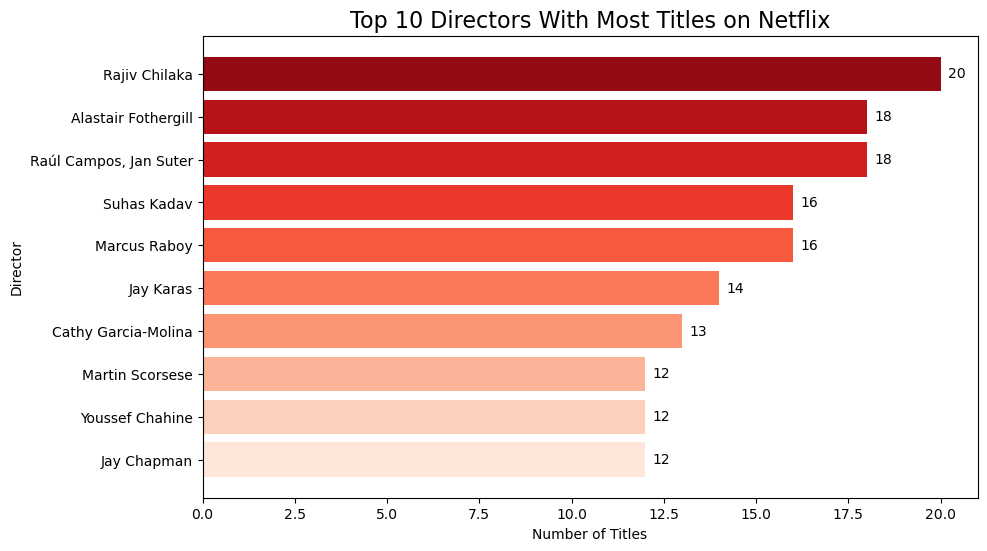

In [24]:
top10_directors = (data['director'].value_counts().loc[lambda x: x.index != "Not Given"].head(10))

plt.figure(figsize=(10,6))

bars = plt.barh(top10_directors.index,top10_directors.values,color=sns.color_palette("Reds_r", 10))

plt.title("Top 10 Directors With Most Titles on Netflix", fontsize=16)
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.grid(False)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.2,                              
        bar.get_y() + bar.get_height()/2,
        str(width),
        va='center',
        ha='left',                              
        fontsize=10,
        color='black'
    )

plt.gca().invert_yaxis()
plt.show()




Findings:

Rajiv Chilaka leads with 20 titles.

Raúl Campos jJan Suter and Alastair Fothergill follow and each have 18 titles.

Marcus Raboy and Suhas Kadav have 16 titles each.

Jay Karas – 14 titles, Cathy Garcia-Molina – 13 titles, Martin Scorsese, Youssef Chahine, and Jay Chapman – 12 titles.

A large portion of entries (2,588) have “Not Given”, showing missing director information for many titles.

In [48]:
data.head(2)

,show_id,type,title,director,country,date_added,release_year,rating,duration_text,listed_in,year_added,month_added,day_added,duration_int
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,25,90
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,24,1


6) Duration Distribution of movies and TV shows

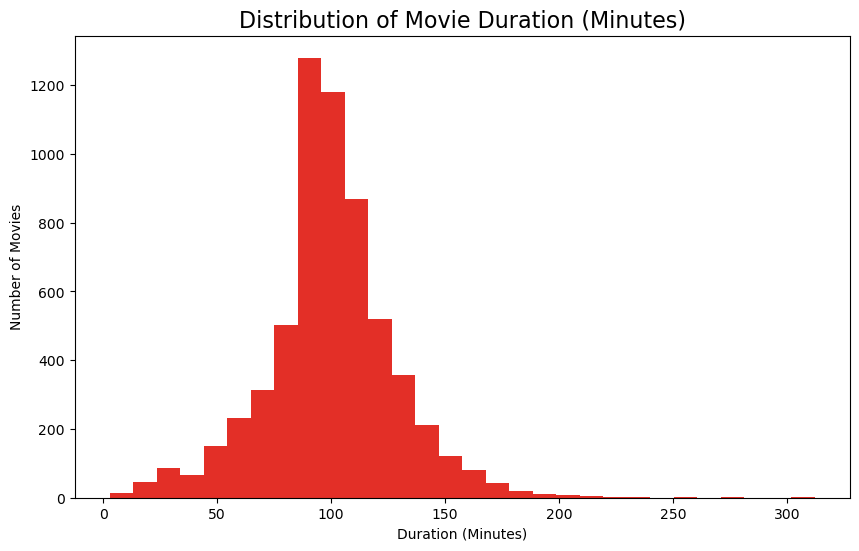

In [25]:
#Distribution of duration by movies

movies = data[data['type'] == 'Movie']
plt.figure(figsize=(10,6))
plt.hist(movies['duration_int'],bins=30,color=sns.color_palette("Reds", 5)[3])

plt.title("Distribution of Movie Duration (Minutes)", fontsize=16)
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.grid(False)

plt.show()

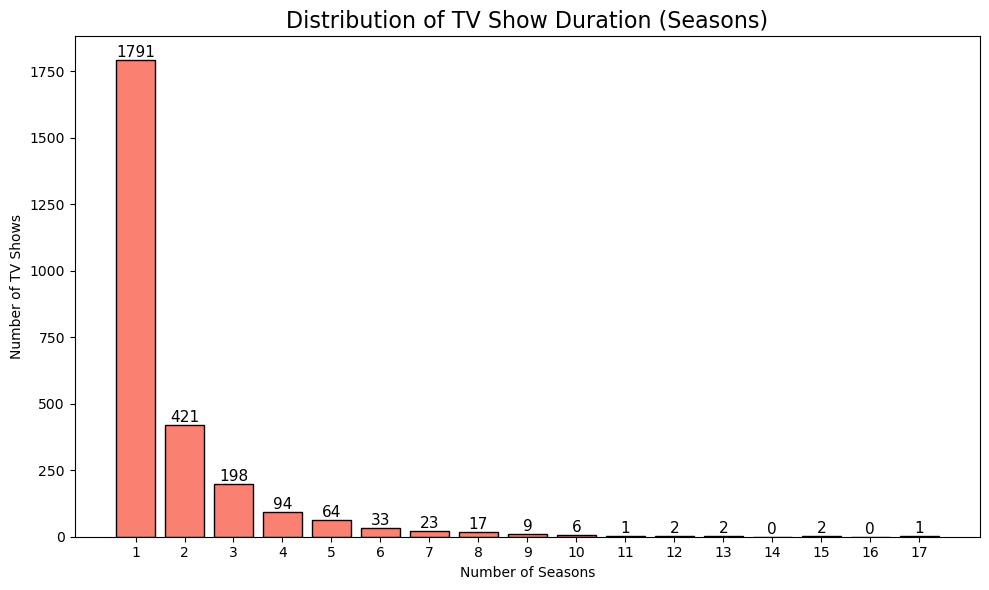

In [44]:
#Distribution of duration by TV shows

tv_shows = data[data['type'] == 'TV Show']
season_counts = tv_shows['duration_int'].value_counts().sort_index()
x_values = list(range(1, season_counts.index.max() + 1))
y_values = [season_counts.get(x, 0) for x in x_values]

plt.figure(figsize=(10,6))

bars = plt.bar(x_values,y_values,color='salmon',edgecolor='black')

plt.title("Distribution of TV Show Duration (Seasons)", fontsize=16)
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.grid(False)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        str(int(height)),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.xticks(x_values)  
plt.tight_layout()
plt.show()



Findings:

-Movies

Average movie length is around 100 minutes.

Most movies fall between 85 to 115 minutes.

The shortest movie is 3 minutes, and the longest is 312 minutes.

-TV Shows

Most TV shows have only 1 season.

Average number of seasons is about 1.7 seasons.

Very few shows run longer than 5 seasons, with the maximum reaching 17 seasons.

It shows that Netflix mainly focuses on standard-length movies and short-running TV series rather than long multi-season shows.

7) Genres with Most Contents

In [27]:
data['listed_in'].value_counts()

Dramas, International Movies                                362
Documentaries                                               359
Stand-Up Comedy                                             334
Comedies, Dramas, International Movies                      274
Dramas, Independent Movies, International Movies            252
                                                           ... 
Anime Features                                                1
Action & Adventure, Horror Movies, Independent Movies         1
Action & Adventure, Classic Movies, International Movies      1
Cult Movies, Independent Movies, Thrillers                    1
Classic & Cult TV, Crime TV Shows, TV Dramas                  1
Name: listed_in, Length: 513, dtype: int64

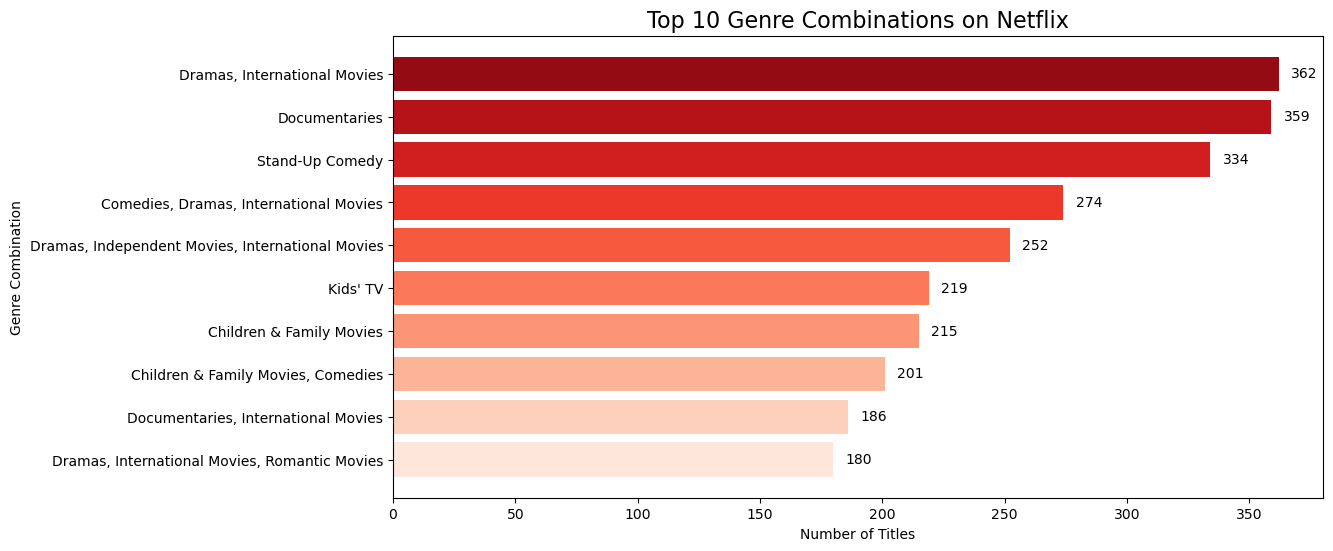

In [28]:
top10_genres_raw = data['listed_in'].value_counts().head(10)
plt.figure(figsize=(12,6))

bars = plt.barh(top10_genres_raw.index[::-1],top10_genres_raw.values[::-1],color=sns.color_palette("Reds", 10))

plt.title("Top 10 Genre Combinations on Netflix", fontsize=16)
plt.xlabel("Number of Titles")
plt.ylabel("Genre Combination")
plt.grid(False)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5, 
        bar.get_y() + bar.get_height()/2,
        str(width),
        va='center',
        fontsize=10
    )

plt.show()


Findings:

Dramas, International Movies” is the most common genre combination with 362 titles.

Documentaries alone appear 359 times, showing strong demand for non-fiction content.

Stand-Up Comedy ranks third with 334 titles, highlighting Netflix’s focus on comedy specials.

Comedies, Dramas, International Movies” is another popular combination with 274 titles.

Dramas, Independent Movies, International Movies” appears 252 times, showing Netflix’s emphasis on global and indie drama content.

Netflix has over 500 unique genre combinations, proving the platform offers a highly diverse content mix.

Many genre combinations occur only once, indicating experimentation with niche and hybrid content styles.


Netflix’s most frequent genre combinations revolve around Dramas, International content, Documentaries, and Stand-Up Comedy, reflecting its strategy to deliver emotionally engaging, globally relevant, and variety-driven entertainment.

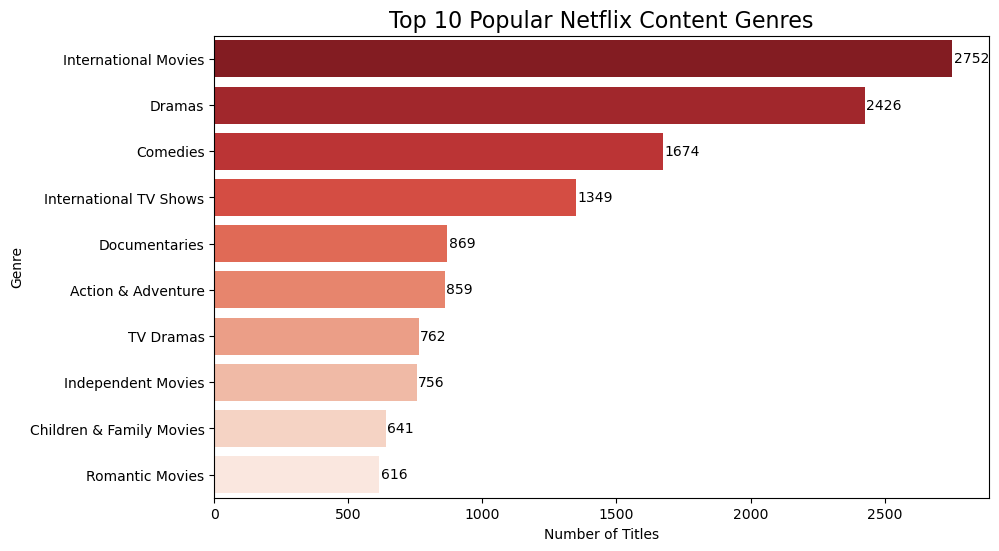

In [29]:

top_genres = genres_data['genre'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='Reds_r')

for index, value in enumerate(top_genres.values):
    plt.text(value + 5, index, str(value), va='center')  

plt.title('Top 10 Popular Netflix Content Genres', fontsize=16)
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

Findings:

Netflix strongly focuses on International content and Dramas, showing its strategy to target a global audience with emotionally engaging stories, while also maintaining a healthy mix of comedies, documentaries, and family-oriented genres.

8) Monthly and Yearly Additions of Contents on Netflix

In [15]:
monthly_movie_additions = data[data['type'] == 'Movie']['month_added'].value_counts().sort_index()
monthly_movie_additions

1     545
2     382
3     528
4     549
5     439
6     492
7     565
8     518
9     518
10    545
11    498
12    547
Name: month_added, dtype: int64

In [17]:
monthly_series_additions = data[data['type'] == 'TV Show']['month_added'].value_counts().sort_index()
monthly_series_additions

1     192
2     180
3     213
4     214
5     193
6     236
7     262
8     236
9     251
10    215
11    207
12    265
Name: month_added, dtype: int64

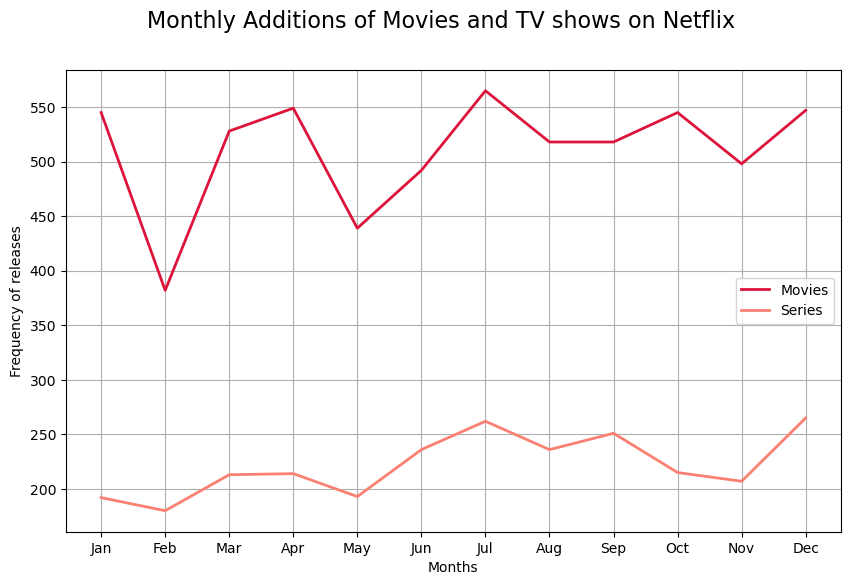

In [30]:
monthly_movie_additions = data[data['type'] == 'Movie']['month_added'].value_counts().sort_index()
monthly_series_additions = data[data['type'] == 'TV Show']['month_added'].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.plot(monthly_movie_additions.index, monthly_movie_additions.values, label='Movies', color='crimson', linewidth=2)
plt.plot(monthly_series_additions.index, monthly_series_additions.values, label='Series', color='salmon', linewidth=2)
plt.xlabel("Months")
plt.ylabel("Frequency of releases")
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend()
plt.grid(True)
plt.suptitle("Monthly Additions of Movies and TV shows on Netflix", fontsize=16)
plt.show()

Findings:

Netflix adds the highest number of titles in July and December.

February has the lowest number of releases for both Movies and TV Shows.

Movie additions remain fairly consistent throughout the year.

TV Show additions show more fluctuation compared to Movies.

The second half of the year (July–December) records more content additions than the first half.

Peak months for Movies: July, December, April, January, and October.

Peak months for TV Shows: December, July, September, June, and August.

Netflix likely schedules more releases during holiday and festive seasons to increase viewer engagement.

These patterns clearly show Netflix’s strategy of releasing more content in the second half of the year and maintaining a stronger focus on movie releases compared to TV series.

In [18]:
yearly_movie_added = data[data['type'] == 'Movie']['year_added'].value_counts().sort_index()
yearly_movie_added

2008       1
2009       2
2010       1
2011      13
2012       3
2013       6
2014      19
2015      56
2016     251
2017     836
2018    1237
2019    1424
2020    1284
2021     993
Name: year_added, dtype: int64

In [19]:
yearly_series_added = data[data['type'] == 'TV Show']['year_added'].value_counts().sort_index()
yearly_series_added

2008      1
2013      5
2014      5
2015     26
2016    175
2017    349
2018    411
2019    592
2020    595
2021    505
Name: year_added, dtype: int64

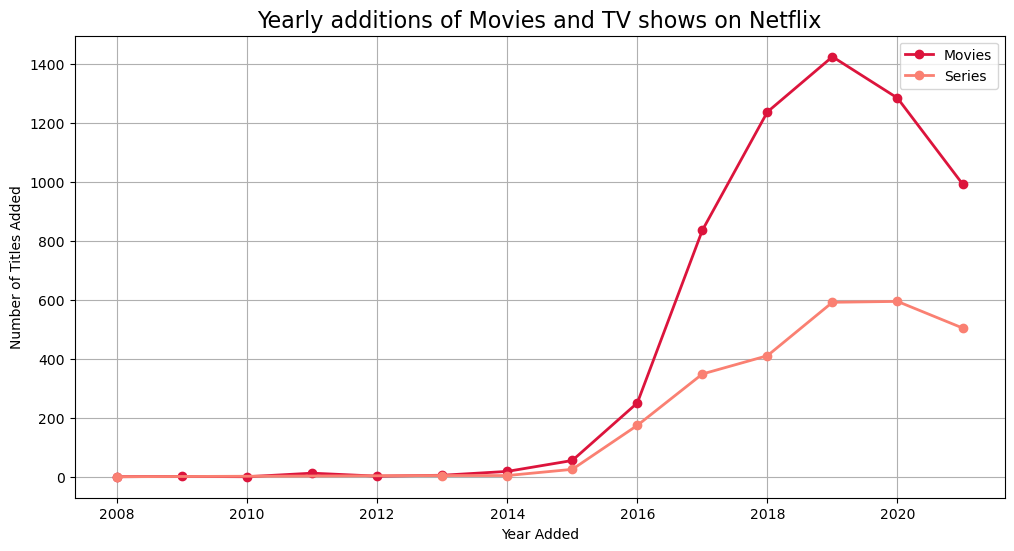

In [31]:
yearly_movie_added = data[data['type'] == 'Movie']['year_added'].value_counts().sort_index()
yearly_series_added = data[data['type'] == 'TV Show']['year_added'].value_counts().sort_index()
plt.figure(figsize=(12,6))
plt.plot(yearly_movie_added.index, yearly_movie_added.values, label='Movies', color='crimson', linewidth=2, marker='o')
plt.plot(yearly_series_added.index, yearly_series_added.values, label='Series', color='salmon', linewidth=2, marker='o')
plt.xlabel("Year Added")
plt.ylabel("Number of Titles Added")
plt.title("Yearly additions of Movies and TV shows on Netflix", fontsize=16)
plt.legend()
plt.grid(True)
plt.show()

Findings:

Netflix added very little content before 2015.

Netflix content additions increased steadily from 2015 onwards.

Movie additions peaked in 2019.

TV Show additions peaked in 2020.

The highest growth is seen between 2017 and 2019 for both Movies and TV Shows.

After 2019, there is a visible decline in new additions.

The reduction in 2020 and later years suggests pandemic-related production slowdowns.

Throughout all years, Movies consistently outnumber TV Shows in yearly additions.

The period 2016–2020 represents Netflix’s major expansion phase.

9) Top Popular Genres for Movies and TV Shows on Netflix

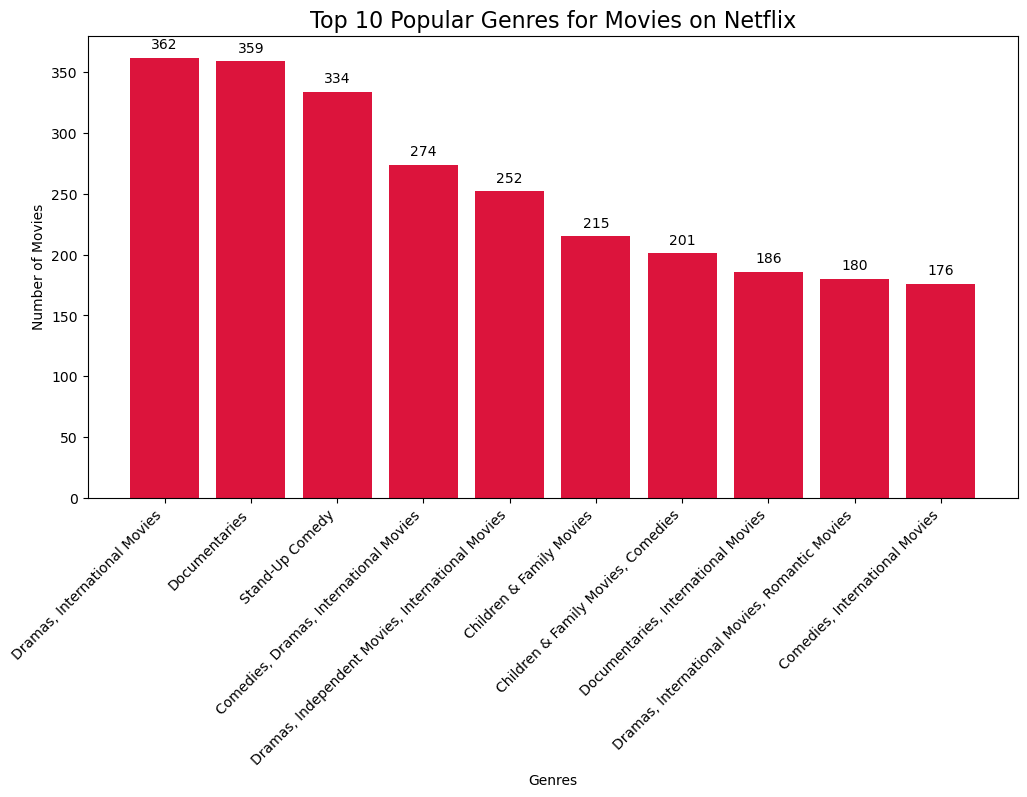

In [32]:
popular_movie_genre = data[data['type'] == 'Movie'].groupby("listed_in").size().sort_values(ascending=False)[:10]
plt.figure(figsize=(12,6))
bars = plt.bar(popular_movie_genre.index, popular_movie_genre.values, color='crimson')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, str(height), ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.xlabel("Genres")
plt.ylabel("Number of Movies")
plt.title("Top 10 Popular Genres for Movies on Netflix", fontsize=16)
plt.show()

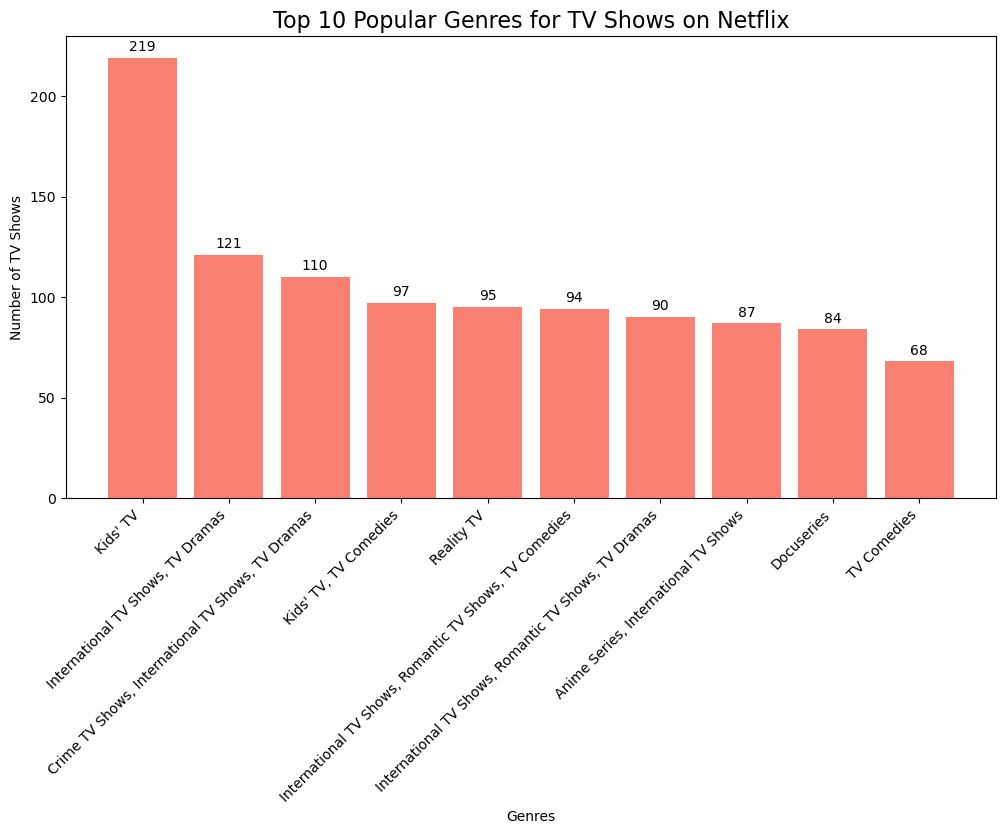

In [33]:
popular_series_genre = data[data['type'] == 'TV Show'].groupby("listed_in").size().sort_values(ascending=False)[:10]
plt.figure(figsize=(12,6))
bars = plt.bar(popular_series_genre.index, popular_series_genre.values, color='salmon')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2, str(height), ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.xlabel("Genres")
plt.ylabel("Number of TV Shows")
plt.title("Top 10 Popular Genres for TV Shows on Netflix", fontsize=16)
plt.show()

Findings:

-Movies

Dramas dominate the movie library, often combined with International or Independent Movies.

Documentaries are highly represented, highlighting Netflix’s focus on educational and factual content.

Stand-Up Comedy ranks third, showing strong popularity of comedy specials.

Family-friendly content appears consistently, with multiple Children & Family Movies in top categories.

Many movies are multi-genre, often combining Drama, Comedy, International, or Romantic categories.

Netflix’s movie library is heavily skewed towards dramas, documentaries, and international content, with comedy and family movies also well represented.

-TV Shows

Kids’ TV shows are the most common, indicating Netflix’s focus on family and children’s content.

International TV Shows and Dramas are popular, reflecting global audience appeal.

Crime, Reality, and Anime appear frequently, showing demand for diverse entertainment.

Multi-genre shows are common, combining elements like Drama, Comedy, and International themes.

Netflix’s TV library focuses on kids and international dramas, with variety across reality, crime, and anime, appealing to a broad global audience.



Netflix prioritizes a balance between adult dramas, educational documentaries, and family/kids content.

Multi-genre content is a key strategy to cater to diverse viewer preferences.

Popular genres reflect global appeal, cross-generational content, and a mix of entertainment and educational offerings.

10) Count of Movies and TV Shows by Rating

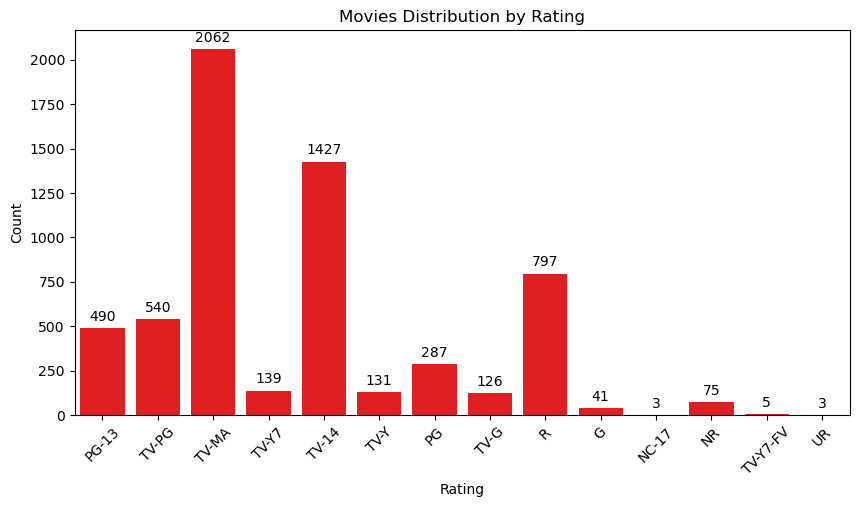

In [40]:
plt.figure(figsize=(10,5))
movie_data = data[data['type'] == 'Movie']
ax = sns.countplot(x='rating', data=movie_data, color='red')
plt.xticks(rotation=45)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Movies Distribution by Rating')
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height}', 
                (p.get_x() + p.get_width()/2., height),
                ha='center', va='bottom', fontsize=10, xytext=(0,3),
                textcoords='offset points')

plt.show()


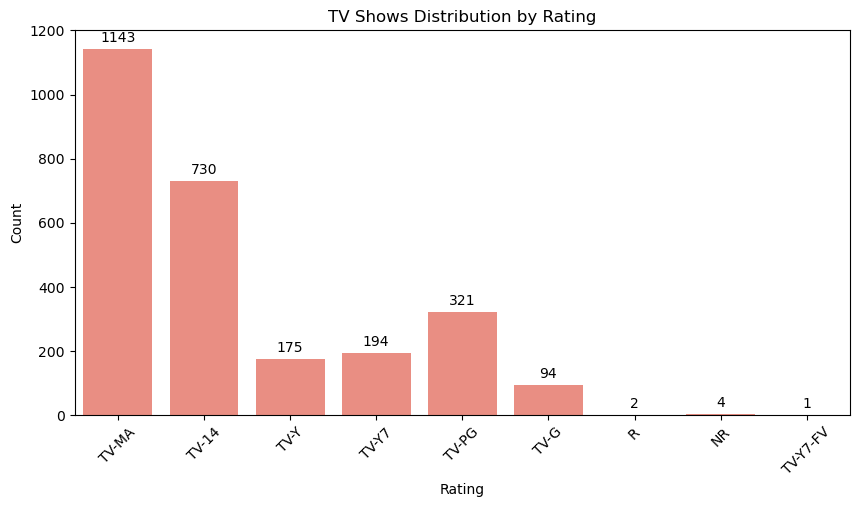

In [45]:
plt.figure(figsize=(10,5))
series_data = data[data['type'] == 'TV Show']
ax = sns.countplot(x='rating', data=series_data, color='salmon')
plt.xticks(rotation=45)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('TV Shows Distribution by Rating')
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height}', 
                (p.get_x() + p.get_width()/2., height),
                ha='center', va='bottom', fontsize=10, xytext=(0,3),
                textcoords='offset points')

plt.show()


Findings:

-Movies

TV-MA (Mature audiences) is the most common rating, followed by TV-14 and R, indicating a focus on adult and teen viewers.

Family/kids content (TV-Y, TV-Y7, TV-G, G) is limited.

Restricted content (NC-17, TV-Y7-FV) is very rare.

-TV Shows

TV-MA shows dominate, targeting mature audiences.

TV-14 is next, appealing to teenagers.

TV-PG provides moderately family-friendly content for general audiences with parental guidance.

Kids content (TV-Y, TV-Y7, TV-G) exists but forms a smaller segment.

Restricted content (R, NR, TV-Y7-FV) is minimal.



Netflix’s library skews heavily toward adult and teen audiences, with TV-PG bridging moderate content for family/teen viewers.

Kids/family content is present but smaller in proportion.

The distribution aligns with Netflix’s strategy of offering diverse adult entertainment while keeping highly restricted content limited.

11) Top Countries producing Movies and TV Shows

In [50]:
top_countries_movies = (data[(data['type'] == "Movie") &(data['country'] != "Not Given")]['country'].value_counts().head(10))
print(top_countries_movies)

United States     2395
India              976
United Kingdom     387
Canada             187
France             148
Spain              129
Egypt              109
Nigeria             96
Mexico              90
Japan               87
Name: country, dtype: int64


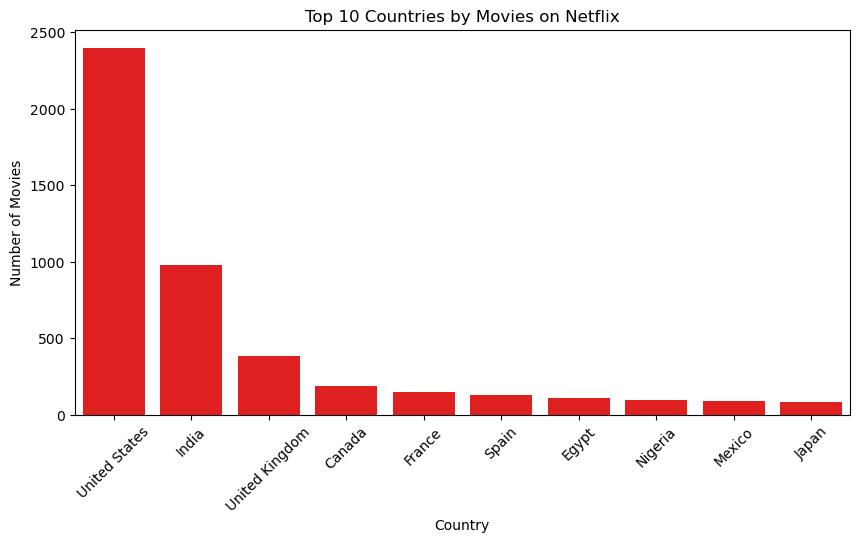

In [54]:
top_countries_movies = top_countries_movies.reset_index()
top_countries_movies.columns = ['country', 'count']

plt.figure(figsize=(10,5))
sns.barplot(data=top_countries_movies, x='country', y='count', color='red')

plt.xticks(rotation=45)
plt.xlabel('Country')
plt.ylabel('Number of Movies')
plt.title('Top 10 Countries by Movies on Netflix')
plt.show()

In [51]:
top_countries_tvshows = (data[(data['type'] == "TV Show") &(data['country'] != "Not Given")]['country'].value_counts().head(10))
print(top_countries_tvshows)

United States     845
Pakistan          350
United Kingdom    251
Japan             172
South Korea       165
Canada             84
India              81
Taiwan             71
France             65
Australia          53
Name: country, dtype: int64


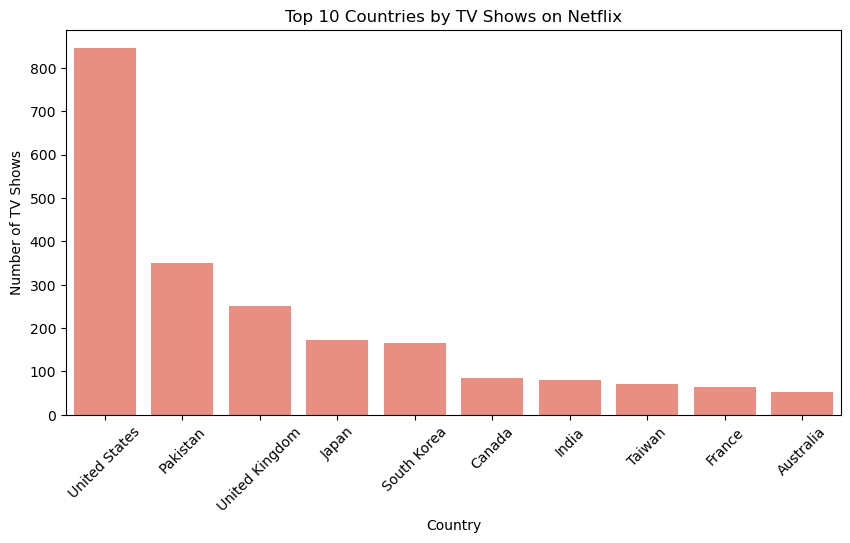

In [55]:
top_countries_tvshows = top_countries_tvshows.reset_index()
top_countries_tvshows.columns = ['country', 'count']

plt.figure(figsize=(10,5))
sns.barplot(data=top_countries_tvshows, x='country', y='count', color='salmon')

plt.xticks(rotation=45)
plt.xlabel('Country')
plt.ylabel('Number of TV Shows')
plt.title('Top 10 Countries by TV Shows on Netflix')
plt.show()

Findings:

US Dominance: The United States leads Netflix’s library, providing the most content for both Movies (2,395 titles) and TV Shows (845 titles).

India’s Movie Power: India is the second-largest source of movies, largely due to Bollywood (976 titles), but contributes significantly fewer TV shows (81 titles).

Asian TV Hubs: Japan and South Korea are key contributors to TV shows, driven by the global popularity of Anime and K-Dramas.

Regional Movie Content: Countries like Nigeria (Nollywood) and Egypt have strong movie representation, showing Netflix’s success in capturing regional film industries.

Concentrated TV Production: TV shows are more concentrated in specific markets such as Pakistan and the UK, whereas movie production is geographically more diverse.

Netflix’s content library reflects a US-heavy focus, with strategic investments in regional movie markets and international TV hubs, ensuring both global and local audience appeal.

**WordCloud for Movies, TV Shows, and Genres**

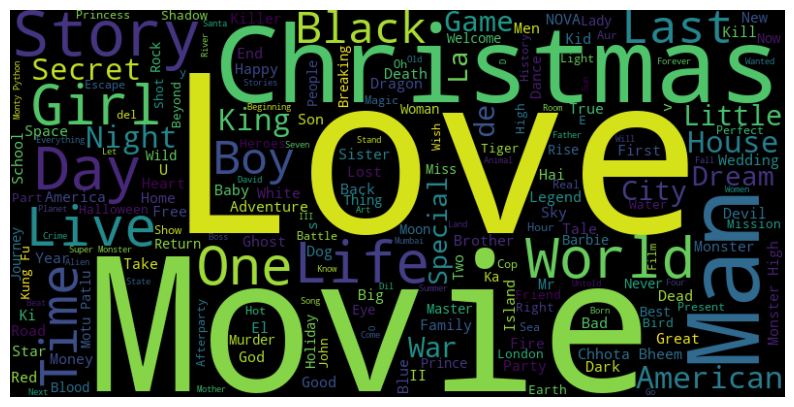

In [36]:
# Generate word cloud for Movie titles
movie_titles = data[data['type'] == 'Movie']['title']
wordcloud = WordCloud(width=800, height=400,
background_color='black').generate(' '.join(movie_titles))
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

-Movie wordcloud

The most dominant words include:

love, life, family, world, young, new, friends, story, father, find, journey, team, group, school, music, woman, man, police, crime, secret, time

It shows:

Netflix movies are largely built around human emotions and relationships — love, family, life, friendship.

A strong storytelling theme of journeys and self-discovery (“journey”, “find”, “new”, “world”).

High presence of youth-centric and coming-of-age themes (“young”, “school”, “friends”).

Crime and mystery terms (“police”, “crime”, “secret”) indicate steady demand for thrillers.

Balanced presence of male and female leads (“man”, “woman”, “father”).

Insight: Netflix movies succeed because they focus on emotion-driven, relatable storytelling that cuts across cultures.

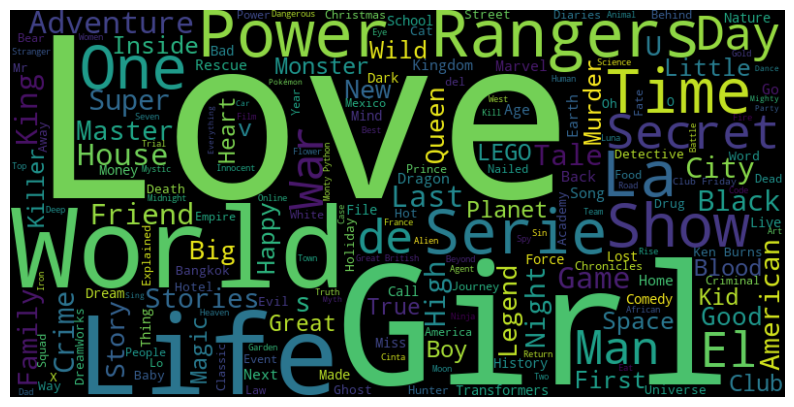

In [37]:
# Generate word cloud for TV Show titles
show_titles = data[data['type'] == 'TV Show']['title']
wordcloud = WordCloud(width=800, height=400,
background_color='black').generate(' '.join(show_titles))
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

-TV Shows wordcloud

Dominant words include:

family, life, young, world, team, school, friends, power, fight, police, crime, war, series, group, secret, city, woman, man

It shows:

TV shows heavily focus on group dynamics and long-form storytelling (“team”, “group”, “series”).

Strong presence of conflict-driven themes — power, fight, war, crime.

Youth & school life themes continue to dominate.

The word “family” appears prominently → emotional bonds drive binge-watch behavior.

Insight: Netflix TV shows are structured around conflict + relationships + long-term character development, which explains their strong retention power.

**Key Insights**

1. Content Mix: Movies vs TV Shows

Netflix’s library is movie-heavy, but TV shows drive long-term engagement.

TV Shows, though fewer, are more likely to keep users subscribed due to episodic nature.

2. Ratings Distribution

-Movies

Dominated by TV-MA, TV-14, and R → Netflix strongly targets adult and teen audiences.

Family and kids content (TV-Y, TV-G, G) forms a much smaller share.

-TV Shows

TV-MA is the top rating, followed by TV-14.

TV-PG (321 titles) acts as a bridge category – moderate family-friendly content.

Kids-only ratings form a minority segment.

Insight: Netflix’s catalogue is clearly skewed toward mature content, not family-centric entertainment.

3. Genre Trends

Top Movie Genres

Dominated by:

Dramas, International Movies

Documentaries

Stand-Up Comedy

Heavy presence of multi-genre combinations (Drama + International, Drama + Romance, Comedy + International).

Top TV Show Genres

Led by:

Kids’ TV

International TV Shows, TV Dramas

Crime TV Shows, International TV Shows, TV Dramas

Anime & Docuseries also appear frequently.

Insight:

Netflix’s movie strategy = Drama + Documentary + Comedy.

Netflix’s TV strategy = Kids + International Dramas + Crime + Anime.

4. Country-wise Content Distribution

Movies

USA is #1 by a huge margin.

India is #2 (Bollywood dominance).

Nigeria & Egypt have strong presence → Netflix has tapped Nollywood & Middle-Eastern cinema.

TV Shows

USA leads, but:

Pakistan ranks #2.

Japan & South Korea are strong contributors (Anime & K-Drama effect).

India contributes far fewer TV shows than movies.

Insight:

Movies are globally diversified.

TV shows are geographically concentrated in a few production hubs.

5. Growth Over Time

Sharp rise in Netflix content after 2015.

Major spike between 2017–2020 → aggressive global expansion phase.

6. Missing & Incomplete Data

Large number of records with:

Missing director names

Multiple genres in a single field

Indicates inconsistent metadata standards across regions.

**Strategic Recommendations**

-Content Strategy

Expand Family & Kids Content

Current library is overly adult-oriented.

Increasing kids/family movies will improve household subscriptions.

Invest More in Indian & Asian TV Shows

India dominates movies but underperforms in TV shows.

Replicate South Korea & Japan’s TV model in India.

Double Down on International Dramas

International TV Dramas consistently rank among top genres.

Localized storytelling is Netflix’s biggest competitive edge.

Boost Documentary + Stand-Up Production

These genres perform strongly in movies and require lower production cost with high ROI.

-Market Expansion

Strengthen Regional Film Industries

Nigeria (Nollywood), Egypt, Mexico show strong movie output.

Create Netflix Originals in these regions to dominate untapped markets.

Reduce Over-reliance on the US

US content dominance exposes Netflix to saturation risk.

Balanced global sourcing will future-proof the library.

-Data & Operations

Standardize Genre Metadata

Split multi-genre values into separate records for accurate analytics.

Improve Missing Director Attribution

Missing values reduce search relevance & recommendation accuracy.

Content Lifecycle Monitoring

Track performance by release year to identify:

Genres losing relevance

Markets needing reinvestment